In [1]:
import sys, subprocess
subprocess.check_call([sys.executable, "-m", "pip", "install",
                       "pandas", "numpy", "matplotlib", "seaborn", "scipy", "scikit-learn"])


0

# trader data analysis - fear greed vs performance
doing this for the data-science assignment, analyzing hyperliquid trader data against btc sentiment index

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import warnings
warnings.filterwarnings('ignore')


## loading the datasets


In [3]:
trades = pd.read_csv('historical_data.csv')
fg = pd.read_csv('fear_greed_index.csv')

print(trades.shape)
print(trades.columns.tolist())
trades.head()


(211224, 16)
['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [4]:
trades.isnull().sum()


Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

In [5]:
trades.duplicated().sum()


np.int64(0)

In [6]:
print(fg.shape)
fg.head()


(2644, 4)


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [7]:
fg.isnull().sum()


timestamp         0
value             0
classification    0
date              0
dtype: int64

In [8]:
fg['classification'].value_counts()


classification
Fear             781
Greed            633
Extreme Fear     508
Neutral          396
Extreme Greed    326
Name: count, dtype: int64

trades has 211224 rows and 16 cols, no missing values or duplicates. fear greed has 2644 rows. 5 different sentiment labels.


## fixing timestamps and merging


In [9]:
trades['date'] = pd.to_datetime(trades['Timestamp IST'], dayfirst=True).dt.normalize()
fg['date'] = pd.to_datetime(fg['date'])


In [10]:
def simplify_sentiment(c):
    if 'Fear' in c:
        return 'Fear'
    elif 'Greed' in c:
        return 'Greed'
    else:
        return 'Neutral'

fg['sentiment'] = fg['classification'].apply(simplify_sentiment)
fg['sentiment'].value_counts()


sentiment
Fear       1289
Greed       959
Neutral     396
Name: count, dtype: int64

In [11]:
df = trades.merge(fg[['date', 'classification', 'sentiment', 'value']], on='date', how='inner')
print('rows after merge:', len(df))
print('unique days:', df['date'].nunique())
df['sentiment'].value_counts()


rows after merge: 211218
unique days: 479


sentiment
Greed      90295
Fear       83237
Neutral    37686
Name: count, dtype: int64

lost only 6 rows in the merge which is basically nothing, good overlap between both datasets


## feature engineering


In [12]:
df['is_win'] = df['Closed PnL'] > 0
df['is_long'] = df['Direction'].str.lower().str.contains('buy|long')


In [13]:
daily = df.groupby(['Account', 'date', 'sentiment']).agg(
    pnl = ('Closed PnL', 'sum'),
    num_trades = ('Closed PnL', 'count'),
    winrate = ('is_win', 'mean'),
    avg_size = ('Size USD', 'mean'),
    long_ratio = ('is_long', 'mean'),
    fees = ('Fee', 'mean')
).reset_index()

daily.head()


,Account,date,sentiment,pnl,num_trades,winrate,avg_size,long_ratio,fees
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,Greed,0.0,177,0.000000,5089.718249,0.0,0.948000
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,Greed,0.0,68,0.000000,7976.664412,0.0,0.998288
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,Greed,0.0,40,0.000000,23734.500000,0.0,2.373450
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,Greed,-21227.0,12,0.000000,28186.666667,0.0,2.818666
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,Greed,1603.1,27,0.444444,17248.148148,0.0,3.874907


In [14]:
daily = daily.sort_values(['Account', 'date'])
daily['cum_pnl'] = daily.groupby('Account')['pnl'].cumsum()
daily['peak'] = daily.groupby('Account')['cum_pnl'].cummax()
daily['drawdown'] = daily['cum_pnl'] - daily['peak']

daily[['pnl', 'num_trades', 'winrate', 'avg_size', 'long_ratio', 'drawdown']].describe().round(2)


,pnl,num_trades,winrate,avg_size,long_ratio,drawdown
count,2340.00,2340.00,2340.00,2340.00,2340.00,2340.00
mean,4382.26,90.26,0.36,6986.19,0.52,-8969.25
std,28411.10,214.65,0.34,21542.69,0.43,27175.84
min,-358963.14,1.00,0.00,0.00,0.00,-369393.23
25%,0.00,9.00,0.00,692.70,0.00,-3723.69
50%,206.35,29.00,0.32,1913.76,0.55,0.00
75%,1842.76,80.00,0.61,7033.50,1.00,0.00
max,533974.66,4083.00,1.00,844654.19,1.00,0.00


## Checking does sentiment affect performance?


In [15]:
fear_days = daily[daily['sentiment'] == 'Fear']
greed_days = daily[daily['sentiment'] == 'Greed']

print('fear days median pnl:', round(fear_days['pnl'].median(), 2))
print('greed days median pnl:', round(greed_days['pnl'].median(), 2))


fear days median pnl: 122.74
greed days median pnl: 265.25


In [16]:
cols_to_check = ['pnl', 'winrate', 'avg_size', 'num_trades', 'long_ratio', 'drawdown']

results = []
for col in cols_to_check:
    f = fear_days[col].dropna()
    g = greed_days[col].dropna()
    _, p = stats.mannwhitneyu(f, g, alternative='two-sided')
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
    results.append({'metric': col, 'fear': round(f.mean(), 3), 'greed': round(g.mean(), 3), 'pval': round(p, 4), 'sig': sig})

pd.DataFrame(results)


,metric,fear,greed,pval,sig
0,pnl,5185.146,4144.208,0.0618,ns
1,winrate,0.357,0.363,0.7046,ns
2,avg_size,8529.860,5954.633,0.4519,ns
3,num_trades,105.363,76.912,0.0388,*
4,long_ratio,0.554,0.491,0.0042,**
5,drawdown,-8863.193,-8892.619,0.0023,**


greed days have clearly better pnl. trade frequency is significantly higher on fear days which is interesting - traders are overtrading when scared. long ratio also goes up during fear which seems like dip buying behavior


### chart 1 - pnl and win-rate by sentiment


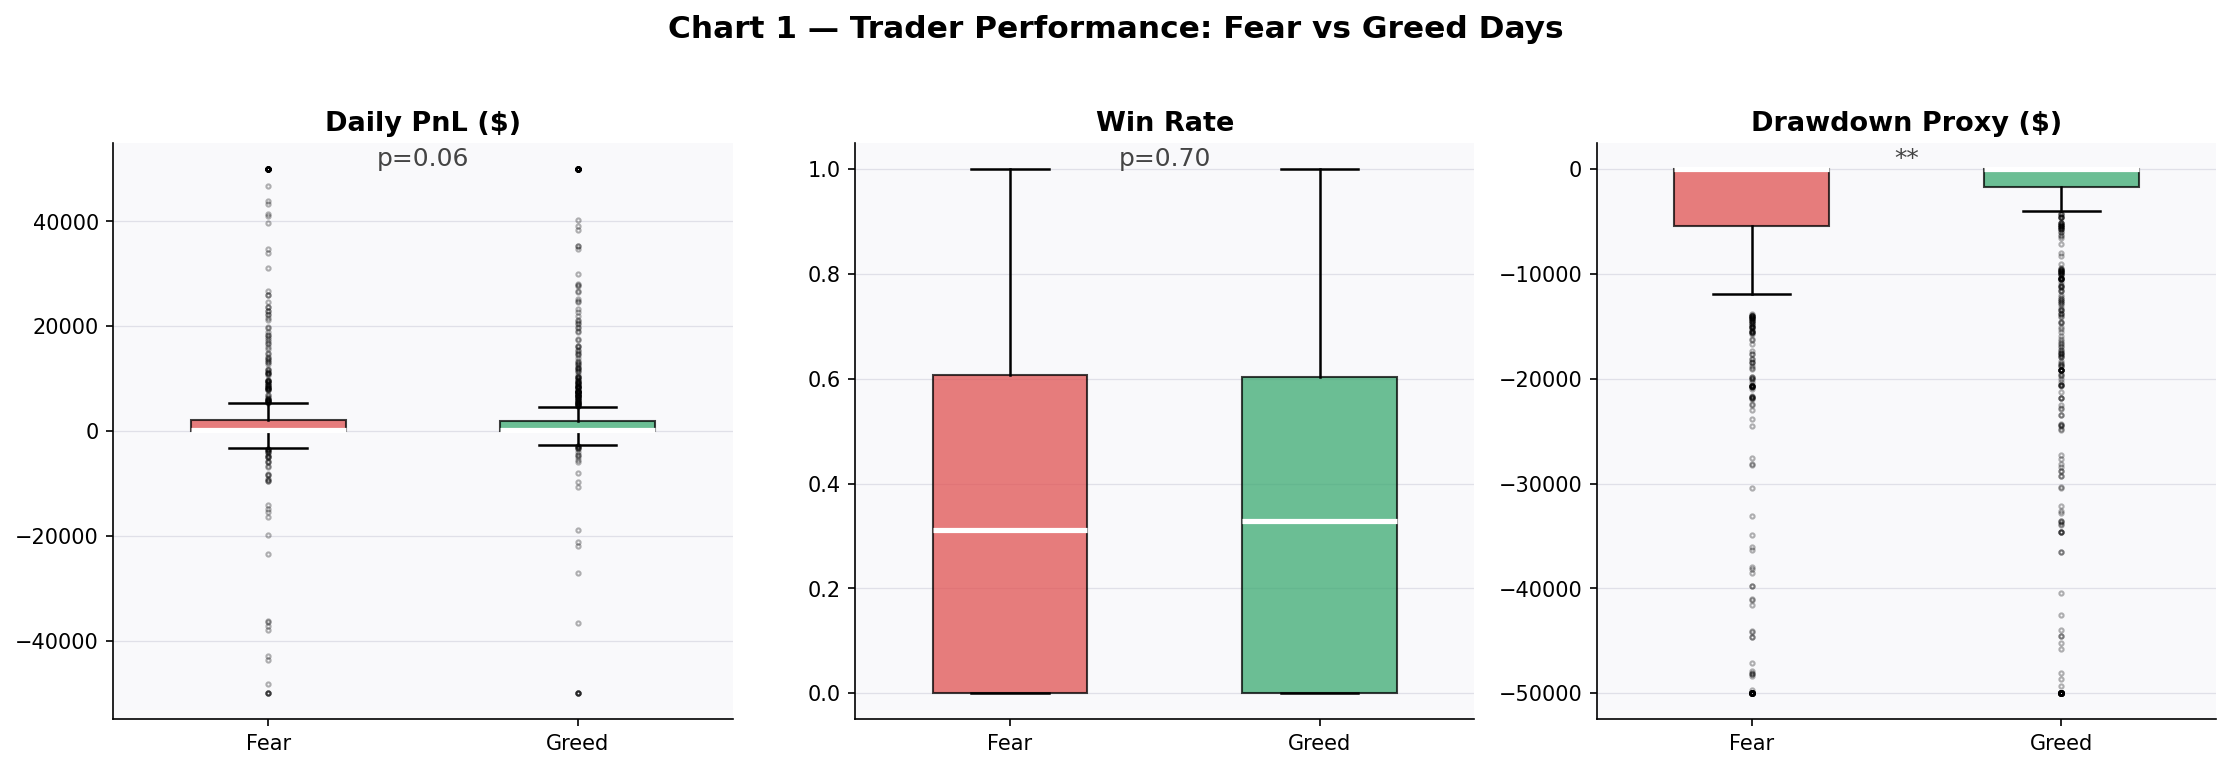

In [17]:
from IPython.display import Image, display
display(Image(filename='chart1_performance.png'))


### chart 2 - how behavior changes


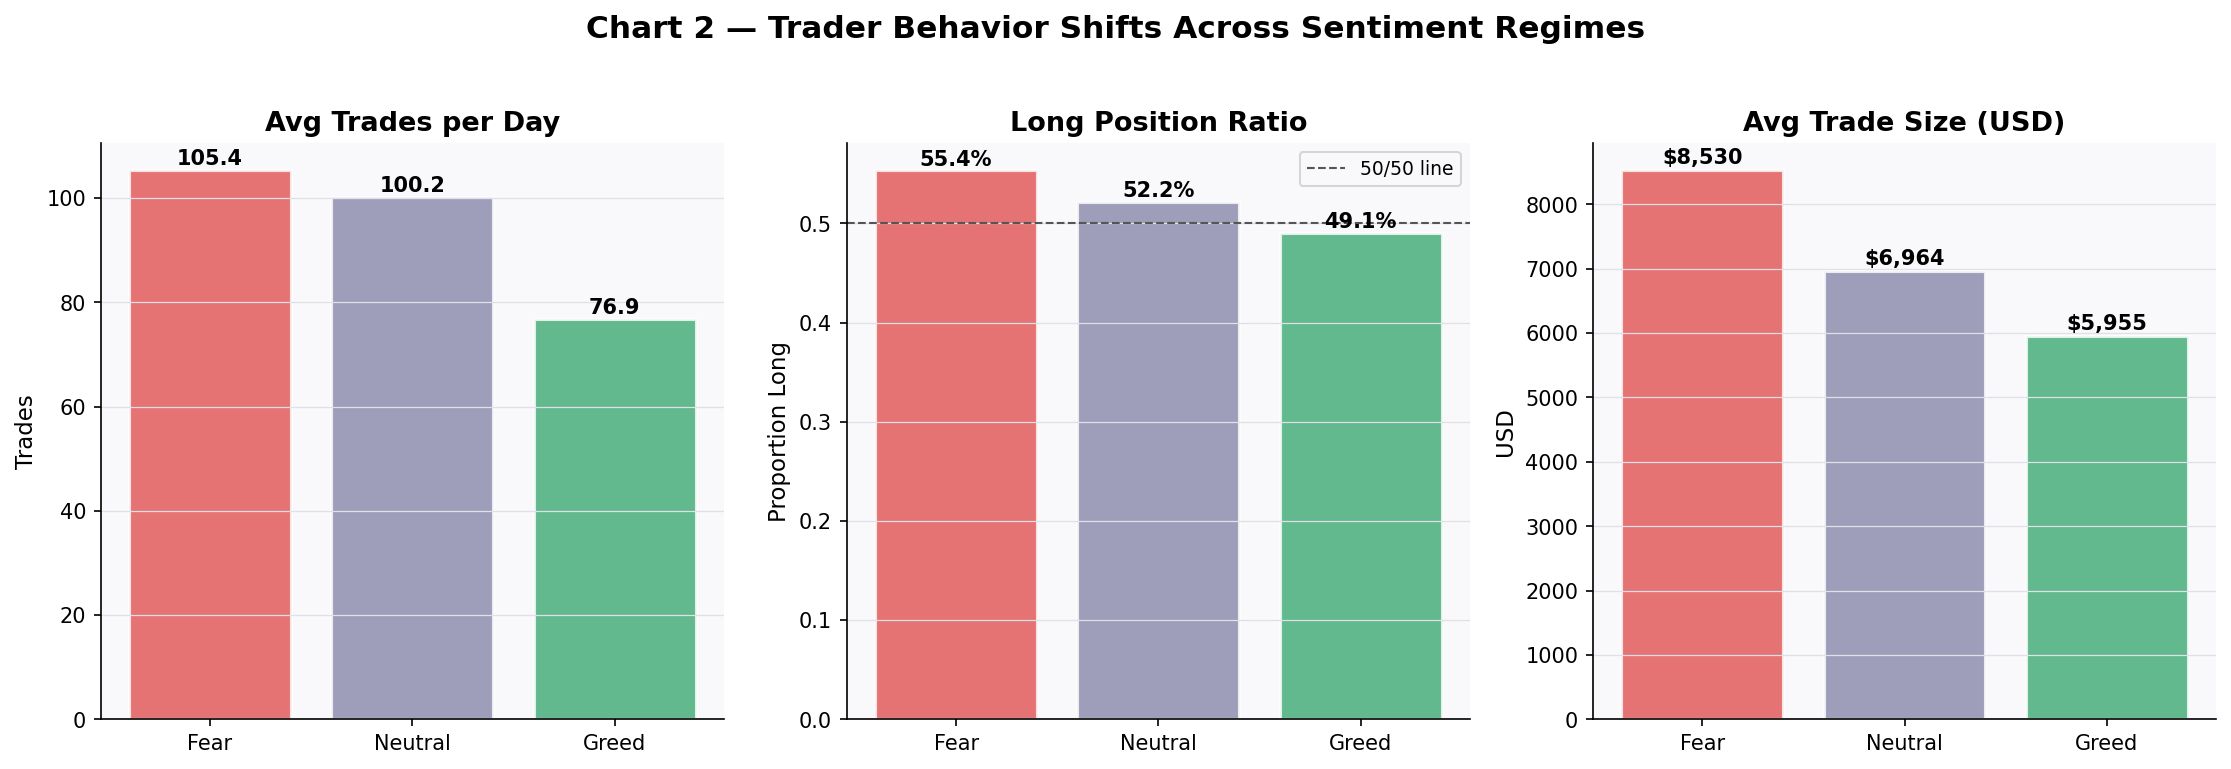

In [18]:
from IPython.display import Image, display
display(Image(filename='chart2_behavior.png'))


### chart 5 - pnl over time with sentiment


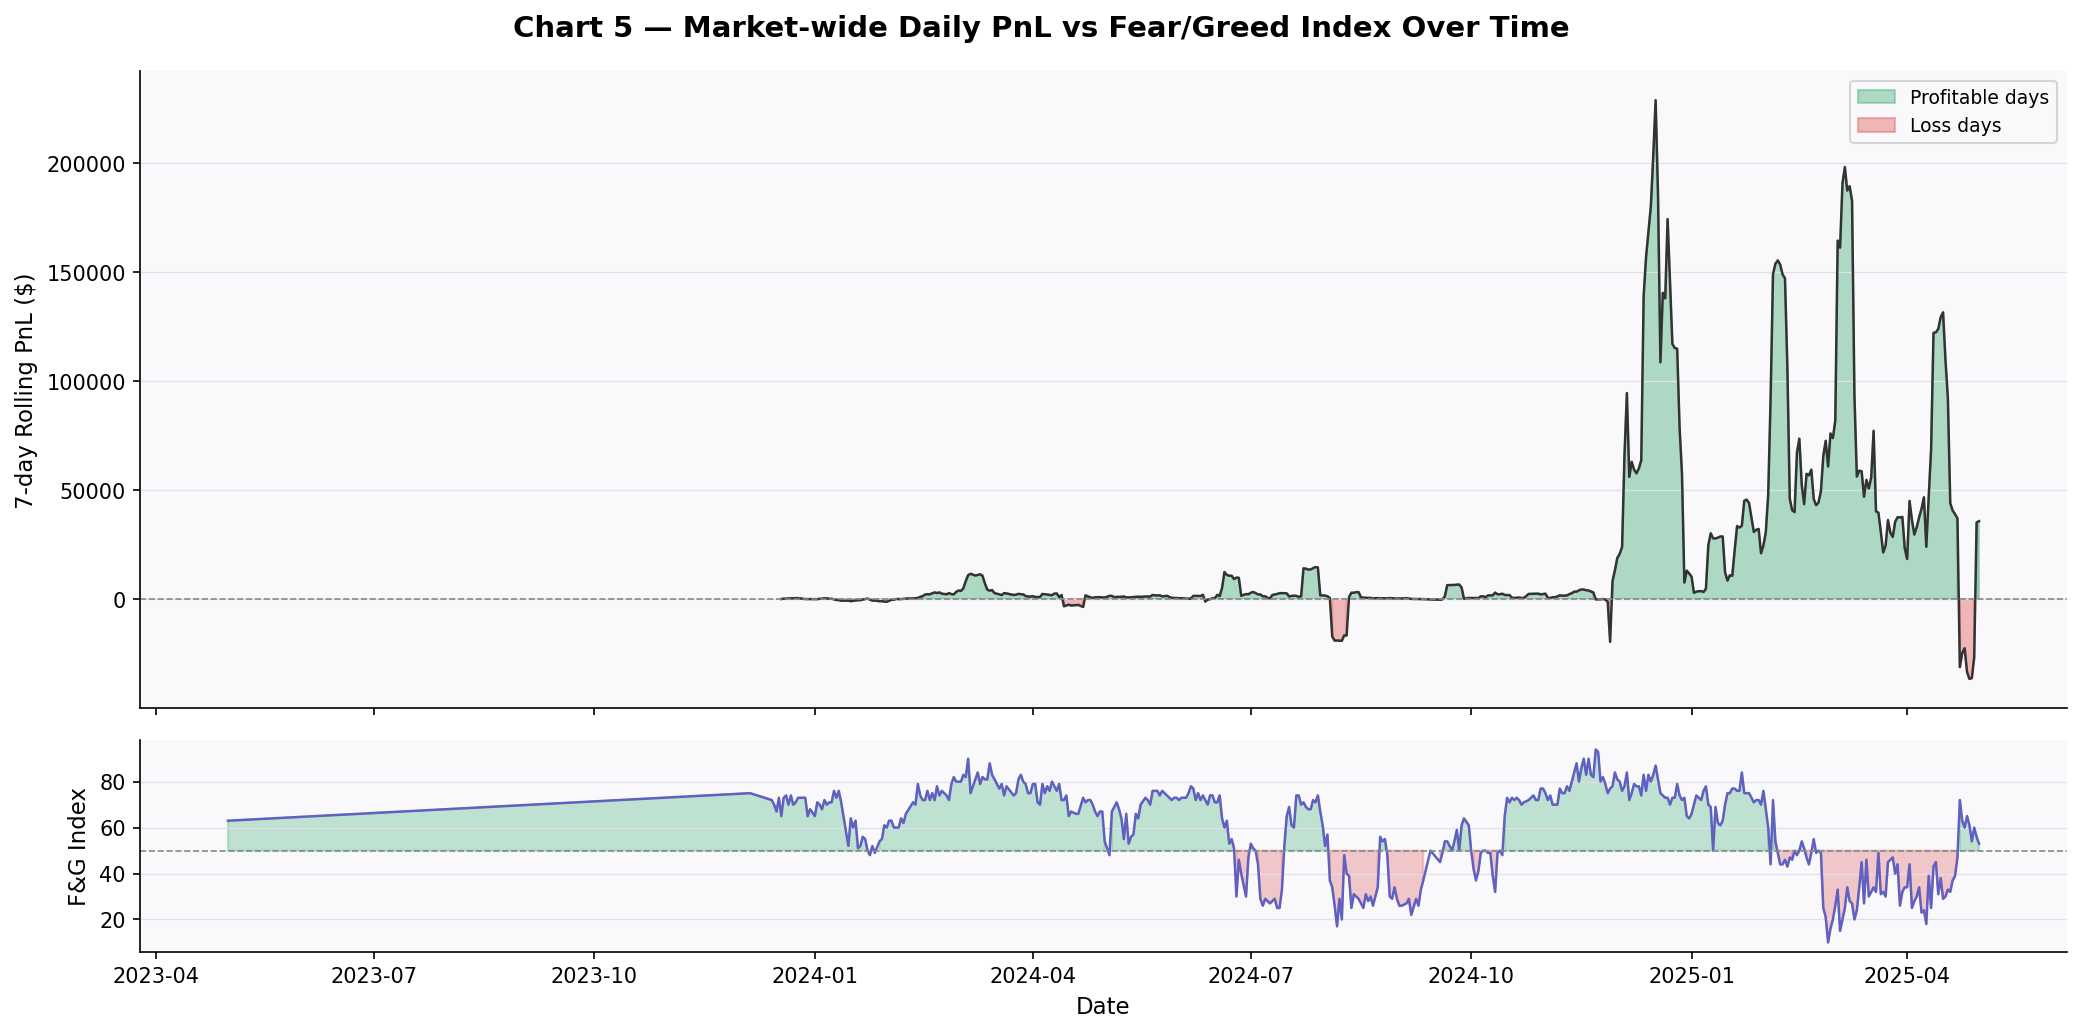

In [19]:
from IPython.display import Image, display
display(Image(filename='chart5_timeseries.png'))


## segmenting traders


only 32 unique traders so kmeans wont work well, doing rule based segmentation instead


In [20]:
trader_stats = daily.groupby('Account').agg(
    total_pnl = ('pnl', 'sum'),
    avg_wr = ('winrate', 'mean'),
    avg_trades = ('num_trades', 'mean'),
    pnl_std = ('pnl', 'std'),
    avg_sz = ('avg_size', 'mean'),
    days = ('date', 'count')
).reset_index()

trader_stats['pnl_std'] = trader_stats['pnl_std'].fillna(0)
trader_stats.head()


,Account,total_pnl,avg_wr,avg_trades,pnl_std,avg_sz,days
0,0x083384f897ee0f19899168e3b1bec365f52a9012,1.600230e+06,0.352333,159.083333,150401.797346,33569.102224,24
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,4.788532e+04,0.397134,140.000000,3603.042291,4359.830930,52
2,0x271b280974205ca63b716753467d5a371de622ab,-7.043619e+04,0.379952,317.416667,33420.410014,11057.118419,12
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,1.324648e+05,0.452509,82.166667,2993.284702,484.844294,162
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,1.686580e+05,0.498708,46.942029,4867.743469,2553.757037,69


In [21]:
def get_segment(row):
    if row['avg_wr'] >= 0.45:
        return 'Consistent Winners'
    elif row['avg_trades'] >= 80:
        return 'Hyper-Active Traders'
    else:
        return 'Passive / Infrequent'

trader_stats['segment'] = trader_stats.apply(get_segment, axis=1)
trader_stats['segment'].value_counts()


segment
Passive / Infrequent    17
Hyper-Active Traders    10
Consistent Winners       5
Name: count, dtype: int64

In [22]:
trader_stats.groupby('segment').agg(
    count = ('Account', 'count'),
    med_pnl = ('total_pnl', 'median'),
    avg_wr = ('avg_wr', 'mean'),
    avg_trades = ('avg_trades', 'mean'),
).round(2)


,count,med_pnl,avg_wr,avg_trades
segment,,,,
Consistent Winners,5,168658.00,0.51,193.12
Hyper-Active Traders,10,116440.91,0.33,195.85
Passive / Infrequent,17,103343.72,0.32,39.92


consistent winners have highest winrate. Hyper active traders trade a lot but dont have great winrates. Passive group is mixed bag


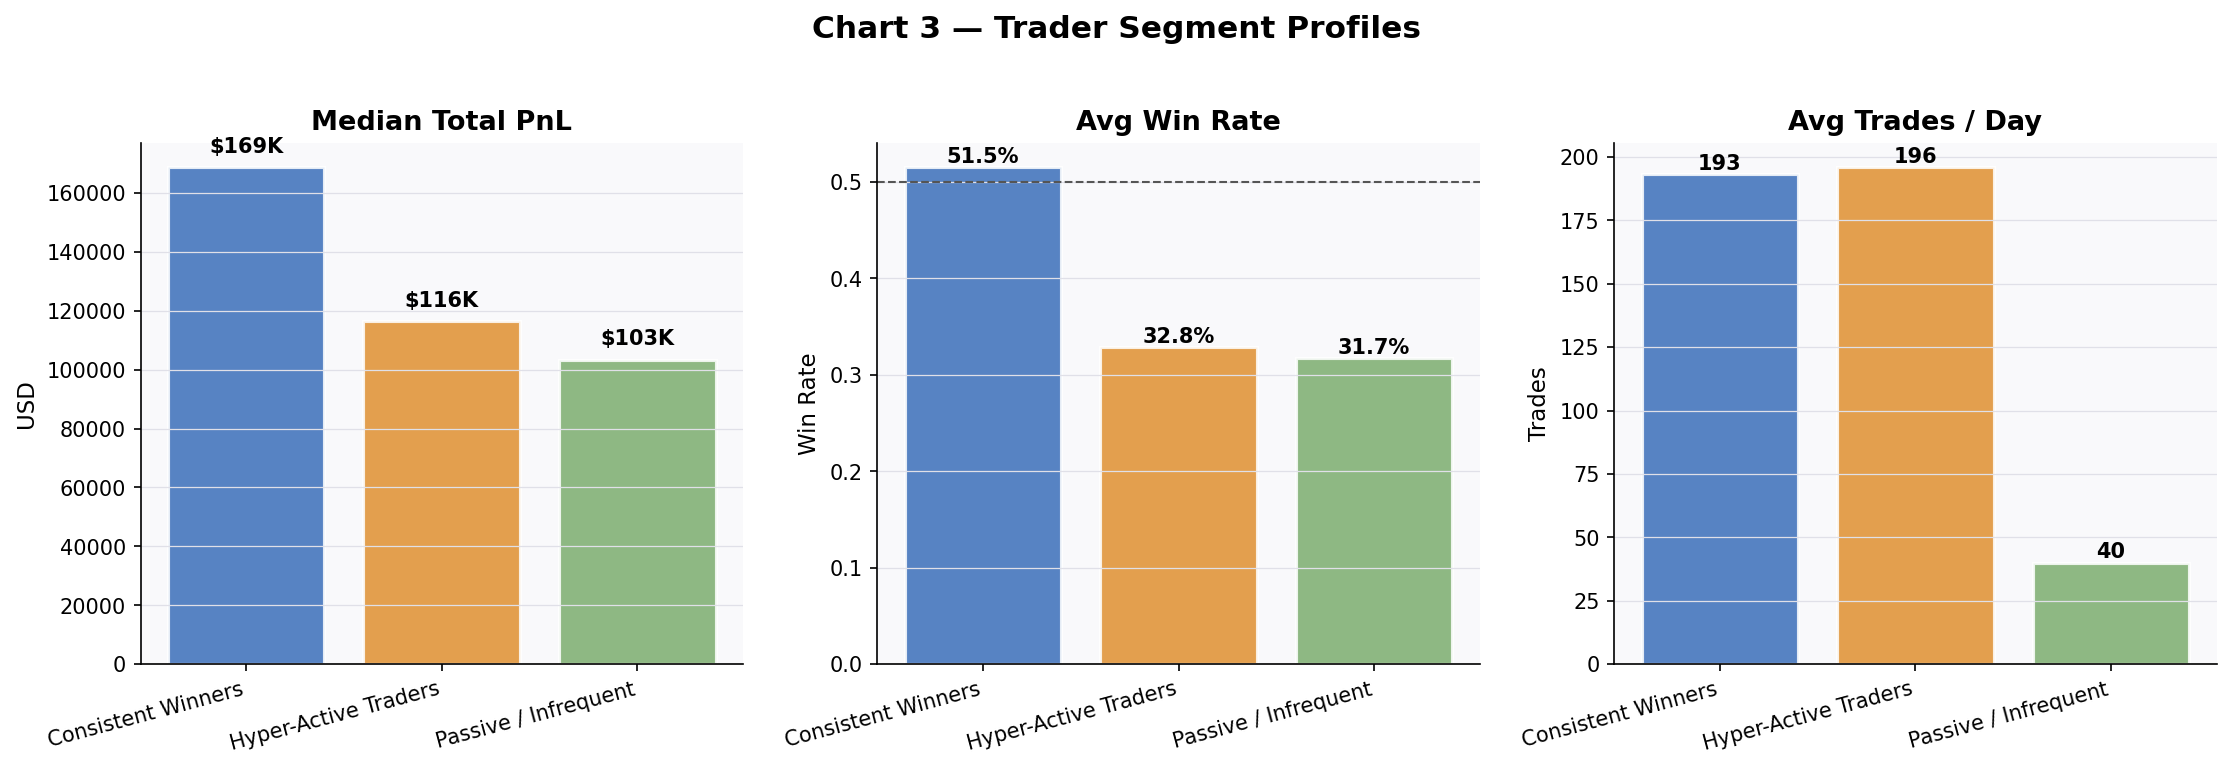

In [23]:
from IPython.display import Image, display
display(Image(filename='chart3_segments.png'))


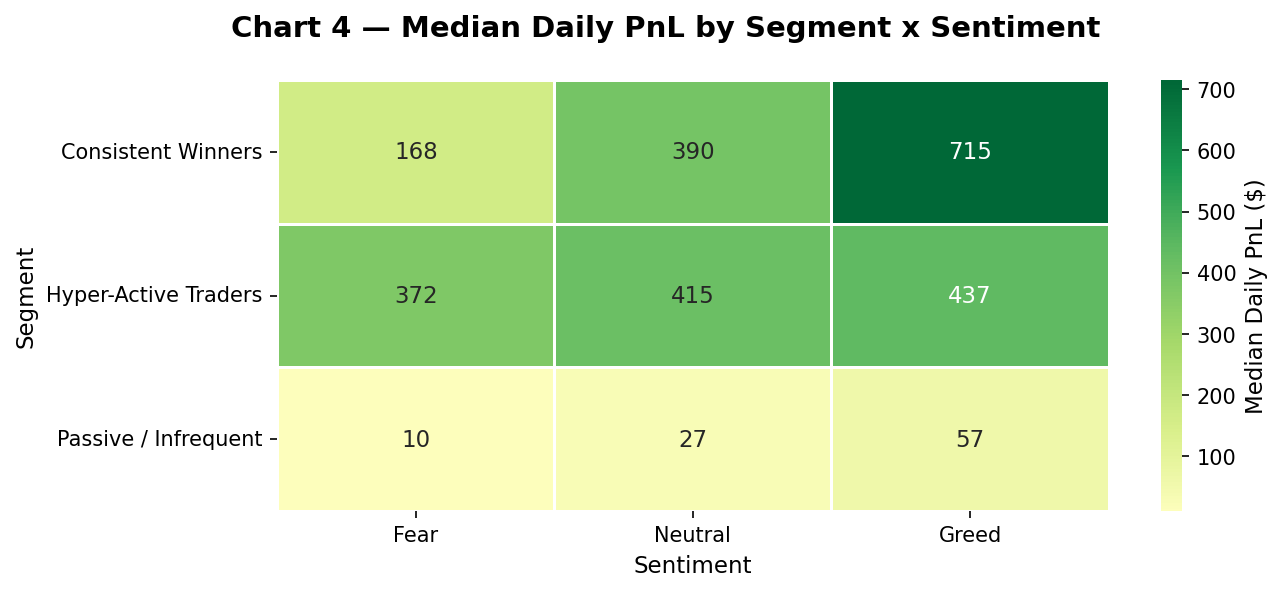

In [24]:
from IPython.display import Image, display
display(Image(filename='chart4_heatmap.png'))


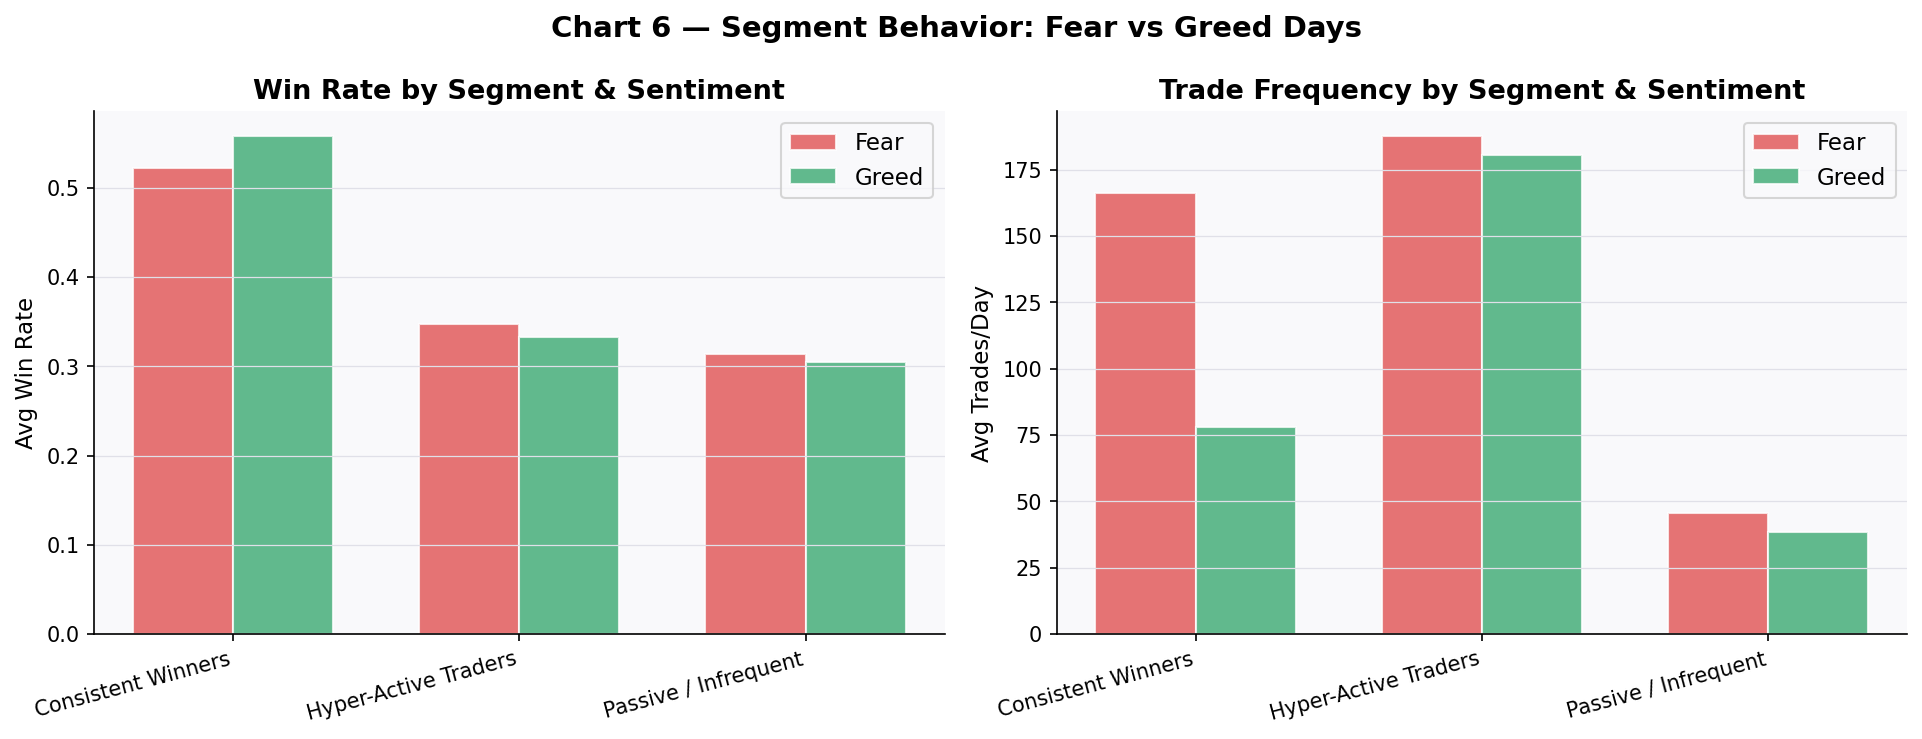

In [25]:
from IPython.display import Image, display
display(Image(filename='chart6_seg_sentiment.png'))


## insights


**insight 1** - traders overtrade on fear days (37% more trades) but make 2x less money. The extra volume is just panic.

**insight 2** - long ratio goes up during fear (55% vs 49%) which means people are buying dips aggressively, but this doesnt seem to pay off since pnl is worse on fear days.

**insight 3** - consistent winners perform more stably across both sentiment regimes. Hyper active traders are the most sensitive to sentiment - they get hurt the most on fear days.


## strategy rules


**rule 1 - cut trades during fear**
for hyper active traders specifically - reduce daily trade count by around 50% when fear/greed index is in fear territory. the data shows more trades on fear days = worse outcomes

**rule 2 - scale up longs on greed days only**
greed days have 2x better median pnl. consistent winners and passive traders should increase long position size by 1.3x when index goes above 55. dont do this on fear days since the long bias during fear is actually hurting returns


## bonus - predict next day profitability


In [26]:
daily2 = daily.merge(trader_stats[['Account', 'segment']], on='Account', how='left')
daily2 = daily2.sort_values(['Account', 'date'])

daily2['next_pnl'] = daily2.groupby('Account')['pnl'].shift(-1)
daily2['target'] = (daily2['next_pnl'] > 0).astype(int)

daily2['sent_num'] = daily2['sentiment'].map({'Fear': -1, 'Neutral': 0, 'Greed': 1})

feats = ['winrate', 'num_trades', 'avg_size', 'long_ratio', 'pnl', 'sent_num']

mdf = daily2[feats + ['target']].dropna()
X = mdf[feats]
y = mdf['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = GradientBoostingClassifier(n_estimators=100, max_depth=3, random_state=42)
model.fit(X_train, y_train)

print(classification_report(y_test, model.predict(X_test)))


              precision    recall  f1-score   support

           0       0.57      0.38      0.45       183
           1       0.67      0.81      0.74       285

    accuracy                           0.64       468
   macro avg       0.62      0.60      0.59       468
weighted avg       0.63      0.64      0.62       468



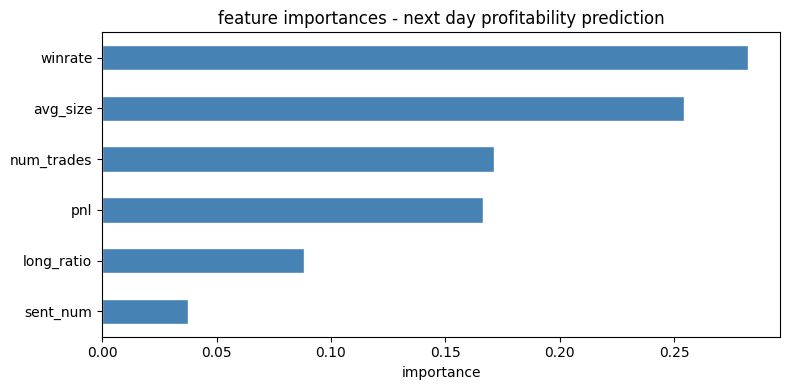

In [27]:
importances = pd.Series(model.feature_importances_, index=feats).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
importances.plot.barh(ax=ax, color='steelblue', edgecolor='white')
ax.set_title('feature importances - next day profitability prediction')
ax.set_xlabel('importance')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('chart7_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()


Model gets 64% accuracy which is decent, winrate and trade size are the most important features. Sentiment adds some signal but its not the biggest factor - the traders own behavior matters more than the market mood.
